In [155]:
import time
from datetime import datetime, timedelta
import os
import numpy as np
import pandas as pd
import requests


from web3 import Web3

from dotenv import load_dotenv
load_dotenv()

True

# Сбор данных

Исторические данные о priority fees из BigQuery:
```
# Сбор данных

with blocks as (
  SELECT timestamp, 
       number as height, 
      --  `hash`,
      --  size,
      --  gas_limit,
      --  gas_used,
       transaction_count,
       base_fee_per_gas
  FROM `bigquery-public-data.crypto_ethereum.blocks` 
  WHERE TIMESTAMP_TRUNC(timestamp, DAY) >= TIMESTAMP("2025-04-15") 
    and TIMESTAMP_TRUNC(timestamp, DAY) < TIMESTAMP("2026-04-16") 
)

select block_timestamp, 
       block_number, 
      --  max(transaction_count) as transaction_count,
      --  max(base_fee_per_gas) as base_fee_per_gas,
       min(priority_fee) AS priority_min,
       APPROX_QUANTILES(priority_fee, 100)[OFFSET(25)] AS priority_p25,
       APPROX_QUANTILES(priority_fee, 100)[OFFSET(50)] AS priority_p50,
       APPROX_QUANTILES(priority_fee, 100)[OFFSET(90)] AS priority_p90,
       APPROX_QUANTILES(priority_fee, 100)[OFFSET(95)] AS priority_p95,

       MAX(priority_fee) AS priority_max
from (
  SELECT 
        block_timestamp,
        block_number, 
        t.`hash` as txn_hash,
        receipt_effective_gas_price - blocks.base_fee_per_gas as priority_fee,
        -- receipt_effective_gas_price,
        -- blocks.base_fee_per_gas as base_fee_per_gas,
        -- max_fee_per_gas,
        -- max_priority_fee_per_gas,
        -- transaction_count
  FROM `bigquery-public-data.crypto_ethereum.transactions` t
  left join blocks on blocks.height = t.block_number
  WHERE
  TIMESTAMP_TRUNC(block_timestamp, DAY) >= TIMESTAMP("2025-04-15") 
    and TIMESTAMP_TRUNC(block_timestamp, DAY) < TIMESTAMP("2026-04-16") 
)
group by block_timestamp, block_number
```

In [202]:
df = pd.read_csv('data/priority_fees_2025-04-15_2026-04-15.csv')
df = df.sort_values(by='block_timestamp', ascending=True)

In [203]:
df

,block_timestamp,block_number,priority_min,priority_p25,priority_p50,priority_p90,priority_p95,priority_max
620623,2025-04-15 00:00:11 UTC,22270668,0,50000000,1000000000,2013072063,3046418307,389514320437
1412193,2025-04-15 00:00:23 UTC,22270669,0,3267842,887974443,2000000000,2000000000,58095682330
2615469,2025-04-15 00:00:35 UTC,22270670,0,0,0,2000000000,5010000000,29984085801
956955,2025-04-15 00:00:47 UTC,22270671,0,1778011,100302441,2000000000,2001000000,54423179351
167934,2025-04-15 00:00:59 UTC,22270672,0,49132751,500000000,2000000000,2015431796,9000000000
...,...,...,...,...,...,...,...,...
1368498,2026-04-15 23:59:11 UTC,24888657,0,137500,4001166,2000000000,2000000000,4945199664
1185859,2026-04-15 23:59:23 UTC,24888658,0,137500,6422989,2000000000,2995464366,9552622506
1949296,2026-04-15 23:59:35 UTC,24888659,0,4700593,50000000,2000000000,2000000000,10375995280
952440,2026-04-15 23:59:47 UTC,24888660,0,1000000,5057452,1272092913,2000000000,5000000000


Добавим признаки, относящиеся только к блокам:

In [204]:
df_blocks = pd.read_csv('data/eth_blocks_2025-04-15_2026-04-15.csv')
df_blocks

,timestamp,height,hash,size,gas_limit,gas_used,transaction_count,base_fee_per_gas
0,2025-12-11 23:47:59 UTC,23992805,0x27273e2e6f523edccedec299babc72c8841343049dfb...,154517,59824395,59072558,232,107248509
1,2025-12-11 10:08:23 UTC,23988743,0x8652b2712f30e65c0419c260d29c72b42816a8ef24bf...,116452,59941066,23494422,297,129667207
2,2025-12-11 13:32:23 UTC,23989754,0x4f32bf081fec9d65fc2c49c8efffe1e0e2036f8e2a27...,196812,59999829,47224397,385,111763769
3,2025-12-11 07:27:35 UTC,23987946,0x086539c9ed8b7b6f5ec4fafc2af7133f8340df1e1ec2...,51108,60058535,17217624,188,129857135
4,2025-12-11 15:48:35 UTC,23990434,0x571ac95e54986cc3630d99f32497d8f07ad5947f05ea...,143688,59882873,27927661,370,119736588
...,...,...,...,...,...,...,...,...
2617989,2025-11-28 14:00:59 UTC,23897632,0xc1d87322b51b6463ac543bdbba0eb6402628236903c7...,48350,60000000,11098802,144,77760089
2617990,2025-11-28 12:08:23 UTC,23897075,0xd8057b22a20e844395da1bd401271ce21ea4d33c6b23...,42297,60000000,11780026,193,85375569
2617991,2025-11-28 15:10:11 UTC,23897975,0x11b81f3de7e8c757cb488c6a52e371bc1229fd458cf5...,189843,60000000,32305085,355,110267057
2617992,2025-11-28 05:26:47 UTC,23895086,0x7d8ddb94323b8b2a2c7f95d2834449e858983374ae5c...,122609,60000000,51125368,246,49792442


In [205]:
blocks_priority = (
    df[['block_timestamp', 'block_number',  'priority_min', 'priority_p25', 'priority_p50', 'priority_p90', 'priority_p95', 'priority_max']]
    .merge(
        df_blocks[['height', 'gas_limit', 'gas_used', 'transaction_count', 'base_fee_per_gas']],
        left_on='block_number',
        right_on='height',
        how='inner',
    )
    .rename(columns={'block_timestamp': 'timestamp'})
)

Добавим исторические данные о цене ETH:

In [206]:
eth_prices = pd.read_csv("data/eth_minutes_2025_2026_april.csv")
eth_prices

,UNIT,TIMESTAMP,open,high,low,close,volume,QUOTE_VOLUME,VOLUME_TOP_TIER,QUOTE_VOLUME_TOP_TIER,VOLUME_DIRECT,QUOTE_VOLUME_DIRECT,VOLUME_TOP_TIER_DIRECT,QUOTE_VOLUME_TOP_TIER_DIRECT,datetime
0,MINUTE,1735636080,3378.569323,3380.485797,3378.217773,3380.465130,1767.621519,5.974709e+06,969.995245,3.278723e+06,88.282421,298298.946808,87.683491,296273.130839,2024-12-31 09:08:00
1,MINUTE,1735636140,3380.465130,3382.087644,3379.523548,3381.908966,2500.374313,8.453734e+06,1622.858775,5.487008e+06,133.230708,450299.577347,132.825178,448927.966293,2024-12-31 09:09:00
2,MINUTE,1735636200,3381.908966,3383.238625,3381.428658,3382.847440,2221.012152,7.513716e+06,1247.153641,4.219135e+06,188.263742,636652.513877,184.458903,623698.905942,2024-12-31 09:10:00
3,MINUTE,1735636260,3382.847440,3383.516298,3382.149028,3382.240800,1515.060300,5.125635e+06,867.835997,2.936108e+06,85.229725,288205.770504,85.036495,287551.856548,2024-12-31 09:11:00
4,MINUTE,1735636320,3382.240800,3383.575566,3381.438189,3381.591191,1391.147431,4.706566e+06,819.917387,2.773771e+06,78.714229,266118.741873,78.559561,265595.298606,2024-12-31 09:12:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678948,MINUTE,1776372960,2348.273880,2349.231203,2348.246726,2348.750841,820.876028,1.928181e+06,384.685157,9.036218e+05,77.392153,181824.304263,77.213193,181403.799793,2026-04-16 20:56:00
678949,MINUTE,1776373020,2348.750841,2350.121545,2348.742061,2350.092517,790.735872,1.857596e+06,316.991592,7.447421e+05,39.417988,92631.146619,39.184068,92081.202798,2026-04-16 20:57:00
678950,MINUTE,1776373080,2350.092517,2350.835093,2350.090775,2350.606920,1446.222961,3.399611e+06,682.632807,1.604733e+06,93.014594,218684.195406,89.722034,210947.712405,2026-04-16 20:58:00
678951,MINUTE,1776373140,2350.606920,2350.626563,2350.330366,2350.361710,1734.835391,4.077958e+06,631.004432,1.483291e+06,112.342241,264101.206433,110.295981,259265.263707,2026-04-16 20:59:00


In [207]:
blocks_priority['timestamp'] = pd.to_datetime(blocks_priority['timestamp']).dt.tz_localize(None) # убираем timezone, чтобы не было проблем при объединении с ценами
eth_prices['datetime'] = pd.to_datetime(eth_prices['datetime']).dt.tz_localize(None)

In [208]:
blocks_priority = blocks_priority.sort_values('timestamp')
eth_prices = eth_prices.sort_values('datetime')

In [209]:
priority_blocks_with_price = pd.merge_asof(
    blocks_priority,
    eth_prices[['datetime', 'close']],
    left_on='timestamp',
    right_on='datetime',
    direction='backward' # чтобы избежать утечки будущего, всегда берем последнее известное значение цены
)

In [210]:
priority_blocks_with_price.drop(columns=['datetime', 'height'], inplace=True)

In [211]:
priority_blocks_with_price.rename(columns={"close": "last_eth_price", "block_number": "height"}, inplace=True)

In [212]:
priority_blocks_with_price

,timestamp,height,priority_min,priority_p25,priority_p50,priority_p90,priority_p95,priority_max,gas_limit,gas_used,transaction_count,base_fee_per_gas,last_eth_price
0,2025-04-15 00:00:11,22270668,0,50000000,1000000000,2013072063,3046418307,389514320437,35929725,30809730,244,378221989,1624.928957
1,2025-04-15 00:00:23,22270669,0,3267842,887974443,2000000000,2000000000,58095682330,35894639,22815810,223,412025557,1624.928957
2,2025-04-15 00:00:35,22270670,0,0,0,2000000000,5010000000,29984085801,35859587,4470024,33,425996604,1624.928957
3,2025-04-15 00:00:47,22270671,0,1778011,100302441,2000000000,2001000000,54423179351,35824569,27135078,287,386022524,1624.928957
4,2025-04-15 00:00:59,22270672,0,49132751,500000000,2000000000,2015431796,9000000000,35789586,12797878,126,410867249,1624.928957
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2616611,2026-04-15 23:59:11,24888657,0,137500,4001166,2000000000,2000000000,4945199664,60000000,32542067,239,46880934,2360.237638
2616612,2026-04-15 23:59:23,24888658,0,137500,6422989,2000000000,2995464366,9552622506,60000000,9933771,98,47377494,2360.237638
2616613,2026-04-15 23:59:35,24888659,0,4700593,50000000,2000000000,2000000000,10375995280,59941408,21864727,185,43416296,2360.237638
2616614,2026-04-15 23:59:47,24888660,0,1000000,5057452,1272092913,2000000000,5000000000,59882873,28125264,220,41948482,2360.237638


In [213]:
priority_blocks_with_price.to_csv("data/priority_with_price_until_april.csv", index=False)

# Feature engineering

Cоздадим несколько горизонтов прогнозирования.
В Ethereum блок  = 12 сек.

| горизонт   | блоков |
| ---------- | ------ |
| next block | 1      |
| 10 минут   | ~50    |
| 1 час      | ~300   |
| 1 день     | ~7200  |
| 1 неделя   | ~50400 |


In [214]:
df = pd.read_csv('data/priority_with_price_until_april.csv')
df

,timestamp,height,priority_min,priority_p25,priority_p50,priority_p90,priority_p95,priority_max,gas_limit,gas_used,transaction_count,base_fee_per_gas,last_eth_price
0,2025-04-15 00:00:11,22270668,0,50000000,1000000000,2013072063,3046418307,389514320437,35929725,30809730,244,378221989,1624.928957
1,2025-04-15 00:00:23,22270669,0,3267842,887974443,2000000000,2000000000,58095682330,35894639,22815810,223,412025557,1624.928957
2,2025-04-15 00:00:35,22270670,0,0,0,2000000000,5010000000,29984085801,35859587,4470024,33,425996604,1624.928957
3,2025-04-15 00:00:47,22270671,0,1778011,100302441,2000000000,2001000000,54423179351,35824569,27135078,287,386022524,1624.928957
4,2025-04-15 00:00:59,22270672,0,49132751,500000000,2000000000,2015431796,9000000000,35789586,12797878,126,410867249,1624.928957
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2616611,2026-04-15 23:59:11,24888657,0,137500,4001166,2000000000,2000000000,4945199664,60000000,32542067,239,46880934,2360.237638
2616612,2026-04-15 23:59:23,24888658,0,137500,6422989,2000000000,2995464366,9552622506,60000000,9933771,98,47377494,2360.237638
2616613,2026-04-15 23:59:35,24888659,0,4700593,50000000,2000000000,2000000000,10375995280,59941408,21864727,185,43416296,2360.237638
2616614,2026-04-15 23:59:47,24888660,0,1000000,5057452,1272092913,2000000000,5000000000,59882873,28125264,220,41948482,2360.237638


In [215]:
df.columns

Index(['timestamp', 'height', 'priority_min', 'priority_p25', 'priority_p50',
       'priority_p90', 'priority_p95', 'priority_max', 'gas_limit', 'gas_used',
       'transaction_count', 'base_fee_per_gas', 'last_eth_price'],
      dtype='object')

#### Общие признаки для всех горизонтов

In [216]:
# network
df["block_utilization"] = df["gas_used"] / df["gas_limit"]
df["gas_pressure"] = df["gas_used"] - df["gas_limit"] / 2
df["tx_per_gas"] = df["transaction_count"] / (df["gas_used"] + 1)

In [217]:
# distribution
df["priority_spread"] = df["priority_p95"] - df["priority_p50"]
df["priority_tail"] = df["priority_max"] - df["priority_p95"]

In [218]:
# interaction with base fee
df["fee_ratio"] = df["priority_p50"] / (df["base_fee_per_gas"] + 1e-9)
df["fee_diff"] = df["priority_p50"] - df["base_fee_per_gas"]

In [219]:
# time
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['month'] = df["timestamp"].dt.month
df['day'] = df["timestamp"].dt.day
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

In [220]:
df.columns

Index(['timestamp', 'height', 'priority_min', 'priority_p25', 'priority_p50',
       'priority_p90', 'priority_p95', 'priority_max', 'gas_limit', 'gas_used',
       'transaction_count', 'base_fee_per_gas', 'last_eth_price',
       'block_utilization', 'gas_pressure', 'tx_per_gas', 'priority_spread',
       'priority_tail', 'fee_ratio', 'fee_diff', 'month', 'day', 'hour',
       'day_of_week', 'is_weekend'],
      dtype='object')

Сохраним датасет с общими фичами для всех горизонтов

In [221]:
df.to_parquet("data/priority_common_features.parquet.gzip", compression="gzip")

In [222]:
file_size_bytes = os.path.getsize('data/priority_common_features.parquet.gzip')
file_size_mb = file_size_bytes / (1024 * 1024)
print(f'Размер сжатого файла: {file_size_mb:.2f} МБ')

Размер сжатого файла: 192.90 МБ


#### Feature engineering для модели на следующий блок

In [223]:
df_nb = pd.read_parquet("data/priority_common_features.parquet.gzip")
df_nb.sort_values('height', ascending=True, inplace=True)

Целевая переменная медиана priority fee в следующем блоке.

In [224]:
df_nb["target"] = df_nb["priority_p50"].shift(-1)

Лаги

In [225]:
for lag in [1,2,3,5,10]:
    df_nb[f"priority_lag_{lag}"] = df_nb["priority_p50"].shift(lag)
    df_nb[f"util_lag_{lag}"] = df_nb["block_utilization"].shift(lag)

Окна

In [226]:
for w in [5,10,20]:
    df_nb[f"priority_ma_{w}"] = df_nb["priority_p50"].rolling(w).mean()
    df_nb[f"priority_vol_{w}"] = df_nb["priority_p50"].rolling(w).std()

In [228]:
def clean_df(df):
    return (
        df.drop(columns='timestamp')
          .replace([np.inf, -np.inf], np.nan)
          .dropna()
    )

In [229]:
df_nb = clean_df(df_nb)

In [230]:
cols = [c for c in df_nb.columns if c != 'target'] + ['target']
df_nb = df_nb[cols]

In [232]:
df_nb.to_parquet("data/models_datasets/priority/priority_next_block.parquet", index=False)

#### Feature engineering для модели через 10 минут

In [233]:
df_10m = pd.read_parquet("data/priority_common_features.parquet.gzip")
df_10m.sort_values('height', ascending=True, inplace=True)

In [234]:
df_10m["target"] = df_10m["priority_p50"].shift(-50)

In [235]:
for lag in [1,5,10,20,50]:
    df_10m[f"priority_lag_{lag}"] = df_10m["priority_p50"].shift(lag)

In [236]:
for w in [10,20,50]:
    df_10m[f"priority_ma_{w}"] = df_10m["priority_p50"].rolling(w).mean()
    df_10m[f"priority_vol_{w}"] = df_10m["priority_p50"].rolling(w).std()

In [237]:
df_10m["spread_change"] = df_10m["priority_spread"].pct_change(10)
df_10m["tail_change"] = df_10m["priority_tail"].pct_change(50)

In [238]:
df_10m = clean_df(df_10m)

cols = [c for c in df_10m.columns if c != 'target'] + ['target']
df_10m = df_10m[cols]

In [239]:
df_10m.to_parquet("data/models_datasets/priority/priority_10m.parquet", index=False)

#### Feature engineering для модели через 1 час

In [248]:
df_1h = pd.read_parquet("data/priority_common_features.parquet.gzip")
df_1h.sort_values('height', ascending=True, inplace=True)

In [249]:
df_1h["target"] = df_1h["priority_p50"].shift(-300)

In [250]:
for lag in [1,10,50,100,300]:
    df_1h[f"priority_lag_{lag}"] = df_1h["priority_p50"].shift(lag)

In [251]:
for w in [50,100,300]:
    df_1h[f"priority_ma_{w}"] = df_1h["priority_p50"].rolling(w).mean()
    df_1h[f"priority_vol_{w}"] = df_1h["priority_p50"].rolling(w).std()

In [252]:
df_1h["spread_ma_50"] = df_1h["priority_spread"].rolling(100).mean()
df_1h["tail_ma_50"] = df_1h["priority_tail"].rolling(300).mean()

In [253]:
df_1h = clean_df(df_1h)

cols = [c for c in df_1h.columns if c != 'target'] + ['target']
df_1h = df_1h[cols]

In [254]:
df_1h.to_parquet("data/models_datasets/priority/priority_1h.parquet", index=False)

#### Feature engineering для модели через 1 день

In [255]:
df_1d = pd.read_parquet("data/priority_common_features.parquet.gzip")
df_1d.sort_values('height', ascending=True, inplace=True)

In [256]:
df_1d["target"] = df_1d["priority_p50"].shift(-7200)

In [257]:
df_1d["lag_1d"] = df_1d["priority_p50"].shift(7200)
df_1d["lag_2d"] = df_1d["priority_p50"].shift(14400)

In [258]:
df_1d["ma_1d"] = df_1d["priority_p50"].rolling(7200).mean()
df_1d["ma_3d"] = df_1d["priority_p50"].rolling(21600).mean()

In [259]:
df_1d["vol_1d"] = df_1d["priority_p50"].rolling(7200).std()

In [260]:
df_1d["spread_1d"] = df_1d["priority_spread"].rolling(7200).mean()
df_1d["tail_1d"] = df_1d["priority_tail"].rolling(7200).mean()

In [261]:
df_1d["eth_return_1d"] = df_1d["last_eth_price"].pct_change(7200)
df_1d["eth_vol_1d"] = df_1d["last_eth_price"].rolling(7200).std()

In [262]:
df_1d = clean_df(df_1d)

cols = [c for c in df_1d.columns if c != 'target'] + ['target']
df_1d = df_1d[cols]

In [263]:
df_1d.to_parquet("data/models_datasets/priority/priority_1d.parquet", index=False)

#### Feature engineering для модели через 1 неделю

In [264]:
df_1w = pd.read_parquet("data/priority_common_features.parquet.gzip")
df_1w.sort_values('height', ascending=True, inplace=True)

In [265]:
df_1w["target"] = df_1w["priority_p50"].shift(-50400)

In [266]:
df_1w["lag_1d"] = df_1w["priority_p50"].shift(7200)
df_1w["lag_1w"] = df_1w["priority_p50"].shift(50400)

In [267]:
df_1w["ma_1d"] = df_1w["priority_p50"].rolling(7200).mean()
df_1w["ma_7d"] = df_1w["priority_p50"].rolling(50400).mean()

In [268]:
df_1w["trend_week"] = df_1w["ma_1d"] - df_1w["ma_7d"]

In [269]:
df_1w["vol_1d"] = df_1w["priority_p50"].rolling(7200).std()
df_1w["vol_7d"] = df_1w["priority_p50"].rolling(50400).std()

In [270]:
df_1w["spread_7d"] = df_1w["priority_spread"].rolling(50400).mean()
df_1w["tail_7d"] = df_1w["priority_tail"].rolling(50400).mean()

In [271]:
df_1w["eth_return_7d"] = df_1w["last_eth_price"].pct_change(50400)
df_1w["eth_vol_7d"] = df_1w["last_eth_price"].rolling(50400).std()

In [272]:
df_1w["week_of_year"] = df_1w["timestamp"].dt.isocalendar().week

In [273]:
df_1w = clean_df(df_1w)

cols = [c for c in df_1w.columns if c != 'target'] + ['target']
df_1w = df_1w[cols]

In [274]:
df_1w.to_parquet("data/models_datasets/priority/priority_1w.parquet", index=False)

# Train-test split

In [104]:
df = pd.read_parquet("data/priority_blocks_with_features.parquet.gzip")
df

,priority_p50,priority_p90,priority_p95,priority_max,gas_limit,gas_used,transaction_count,base_fee_per_gas,last_eth_price,priority_p90_lag_1,...,hour,day_of_week,hour_sin,hour_cos,is_weekend,target_next_block,target_10m,target_1h,target_1d,target_1w
300,1006763000,2142523750,3000000000,15243468046,30000000,21034762,253,4070361596,3356.479770,2.000000e+09,...,1,2,0.258819,0.965926,0,2.142524e+09,2.000000e+09,2.000000e+09,2.000000e+09,2.105438e+09
301,818893204,2142523750,3092593009,66097293751,30029295,19159565,266,4275058791,3356.479770,2.142524e+09,...,1,2,0.258819,0.965926,0,2.800000e+09,2.434582e+09,3.166606e+09,3.242190e+09,3.775098e+09
302,1000000000,2800000000,4352739829,10000000000,30000000,11224650,161,4422579476,3356.479770,2.142524e+09,...,1,2,0.258819,0.965926,0,2.000000e+09,2.000000e+09,3.135031e+09,2.000000e+09,4.031514e+09
303,956651386,2000000000,2847070566,28538375118,30000000,18064373,199,4283439598,3356.479770,2.800000e+09,...,1,2,0.258819,0.965926,0,3.651327e+09,2.000000e+09,3.000000e+09,3.461553e+09,3.898999e+09
304,1006763000,3651327321,6035835993,12575771005,30000000,6263621,97,4392823403,3359.561649,2.000000e+09,...,1,2,0.258819,0.965926,0,2.000000e+09,2.488590e+09,3.000000e+09,3.429621e+09,4.449253e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2887581,0,100590143332,139881707522,139881707522,59941408,12206803,17,55499822,2141.668081,5.000000e+09,...,23,6,-0.258819,0.965926,1,0.000000e+00,2.000000e+09,1.000000e+09,2.000000e+09,1.965260e+09
2887582,0,0,1000000,49336189915,59999943,39575876,87,51387918,2143.647979,1.005901e+11,...,23,6,-0.258819,0.965926,1,2.794108e+10,4.332853e+09,1.000000e+09,2.100000e+09,1.600000e+09
2887584,1382113358,9940888709,16373991154,37023832971,60000000,56023813,155,59111291,2143.647979,2.794108e+10,...,23,6,-0.258819,0.965926,1,2.000000e+09,2.000000e+09,2.000000e+09,9.427070e+08,2.000000e+09
2887585,1000000000,2000000000,5000000001,97672138378,60000000,33860867,379,65520879,2143.647979,9.940889e+09,...,23,6,-0.258819,0.965926,1,2.000000e+09,7.371068e+07,2.000000e+09,2.641939e+08,1.005625e+09


In [105]:
df.columns

Index(['priority_p50', 'priority_p90', 'priority_p95', 'priority_max',
       'gas_limit', 'gas_used', 'transaction_count', 'base_fee_per_gas',
       'last_eth_price', 'priority_p90_lag_1', 'priority_p90_lag_2',
       'priority_p90_lag_3', 'priority_p90_lag_5', 'priority_p90_lag_10',
       'priority_p90_lag_20', 'priority_p90_lag_50', 'priority_p90_lag_100',
       'priority_p90_ma_5', 'priority_p90_vol_5', 'priority_p90_ma_20',
       'priority_p90_vol_20', 'priority_p90_ma_50', 'priority_p90_vol_50',
       'priority_p90_ma_300', 'priority_p90_vol_300', 'priority_p90_change_1',
       'priority_p90_change_5', 'priority_p90_change_20', 'block_utilization',
       'utilization_change', 'gas_used_change', 'tx_change',
       'eth_price_change_5m', 'eth_price_change_1h', 'eth_vol_5m',
       'eth_vol_1h', 'hour', 'day_of_week', 'hour_sin', 'hour_cos',
       'is_weekend', 'target_next_block', 'target_10m', 'target_1h',
       'target_1d', 'target_1w'],
      dtype='object')

In [106]:
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)

train = df.iloc[:train_size]
val = df.iloc[train_size:train_size + val_size]
test = df.iloc[train_size + val_size:]

In [107]:
targets = [
    "target_next_block",
    "target_10m",
    "target_1h",
    "target_1d",
    "target_1w"
]


In [108]:
target = "target_next_block"

X_train = train.drop(columns=targets)
y_train = train[target]

X_val = val.drop(columns=targets)
y_val = val[target]

X_test = test.drop(columns=targets)
y_test = test[target]

In [109]:
import os
import sys
from lightgbm import LGBMRegressor
from lightgbm import early_stopping, log_evaluation

In [152]:
lgbm = LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.005,
    max_depth=100,
    # subsample=0.8,
    # colsample_bytree=0.8,
    # random_state=42
)

lgbm.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="rmse",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(50)  # вывод каждые 50 итераций 
    ]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028972 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9253
[LightGBM] [Info] Number of data points in the train set: 2017205, number of used features: 41
[LightGBM] [Info] Start training from score 3269735953.671813
Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 2.57147e+10	valid_0's l2: 6.61244e+20
[100]	valid_0's rmse: 2.56969e+10	valid_0's l2: 6.60329e+20
Early stopping, best iteration is:
[84]	valid_0's rmse: 2.56951e+10	valid_0's l2: 6.60236e+20


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,100
,learning_rate,0.005
,n_estimators,5000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [151]:
lgbm.booster_.params["objective"]

'regression'

In [148]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

lgbm_pred = lgbm.predict(X_test)

lgbm_mae = mean_absolute_error(y_test, lgbm_pred)
lgbm_rmse = np.sqrt(mean_squared_error(y_test, lgbm_pred))

print("MAE:", lgbm_mae)
print("RMSE:", lgbm_rmse)

MAE: 1898084653.5155513
RMSE: 21240580187.219494


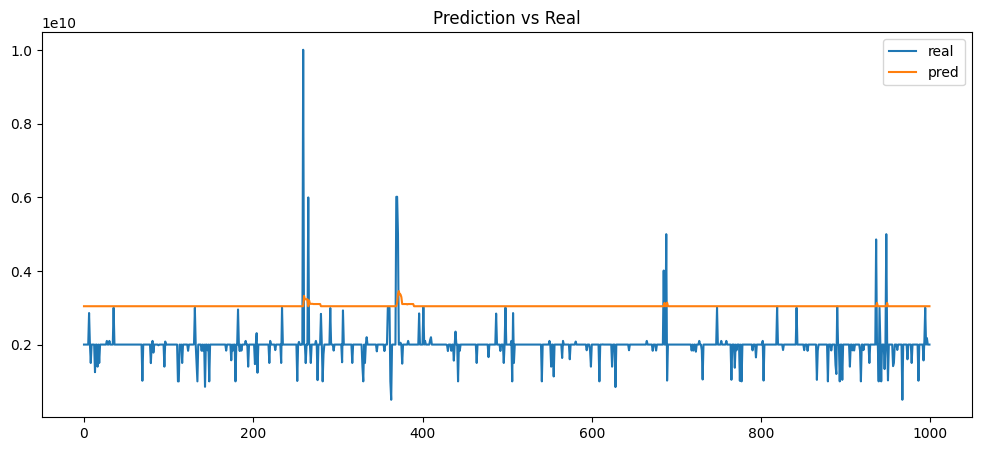

In [149]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values[:1000], label="real")
plt.plot(lgbm_pred[:1000], label="pred")
plt.legend()
plt.title("Prediction vs Real")
plt.show()

In [114]:
baseline_pred = X_test["priority_p90_lag_1"]

mae_baseline = mean_absolute_error(y_test, baseline_pred)

print("Baseline MAE:", mae_baseline)
print("Model MAE:", lgbm_mae)

Baseline MAE: 1163651934.9534283
Model MAE: 1898138446.7207906


In [143]:
lgbm_train_pred = lgbm.predict(X_train)
lgbm_test_pred = lgbm.predict(X_test)

In [144]:
def evaluate(y_true, y_pred, name="set"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"\n{name} results:")
    print(f"MAE : {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")

    return mae, rmse

In [145]:
train_mae, train_rmse = evaluate(y_train, lgbm_train_pred, "TRAIN")
test_mae, test_rmse = evaluate(y_test, lgbm_test_pred, "TEST")


TRAIN results:
MAE : 1,959,662,139.51
RMSE: 59,948,090,442.73

TEST results:
MAE : 1,898,084,653.52
RMSE: 21,240,580,187.22


In [146]:
lgbm_importance = pd.Series(
    lgbm.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(lgbm_importance.head(20))

priority_max             219
priority_p90_ma_5        216
eth_price_change_5m      168
eth_vol_1h               147
priority_p50             132
priority_p90_ma_20       108
base_fee_per_gas         104
priority_p90_change_1    102
eth_vol_5m                94
last_eth_price            92
priority_p90              85
tx_change                 71
priority_p90_lag_50       69
priority_p90_ma_50        67
priority_p90_vol_50       66
priority_p90_change_5     61
priority_p90_lag_20       52
block_utilization         52
priority_p90_vol_20       44
priority_p90_lag_10       44
dtype: int32


In [136]:
from xgboost import XGBRegressor

In [137]:
xgboost = XGBRegressor(
    n_estimators=5000,
    learning_rate=0.05,
    max_depth=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist",
    eval_metric="mae",   
    early_stopping_rounds=50
)

xgboost.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

[0]	validation_0-mae:1885944839.72516
[50]	validation_0-mae:5329394897.67896
[51]	validation_0-mae:5355639459.26962


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [138]:
xgboost_pred = lgbm.predict(X_test)

xgboost_mae = mean_absolute_error(y_test, xgboost_pred)
xgboost_rmse = np.sqrt(mean_squared_error(y_test, xgboost_pred))

print("MAE:", xgboost_mae)
print("RMSE:", xgboost_rmse)

MAE: 1898084653.5155513
RMSE: 21240580187.219494


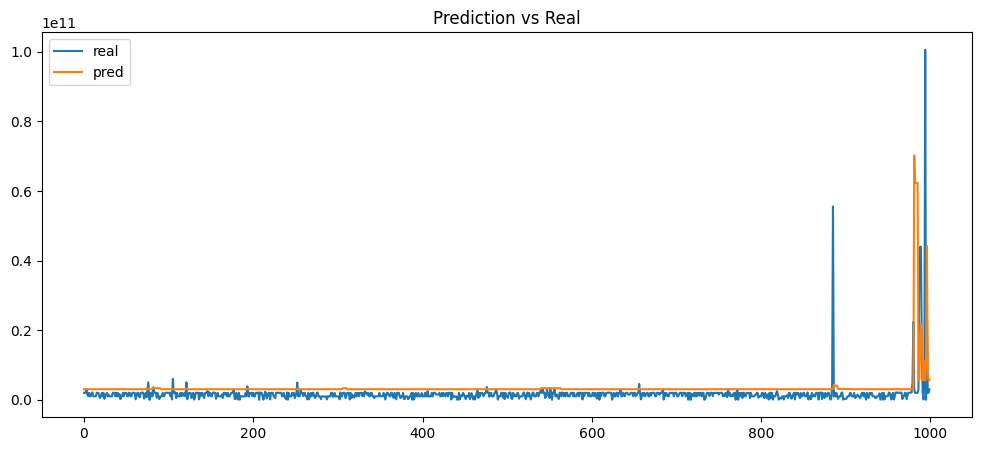

In [142]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values[-1000:], label="real")
plt.plot(xgboost_pred[-1000:], label="pred")
plt.legend()
plt.title("Prediction vs Real")
plt.show()